In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))


In [2]:
from src.rescue_route.weather.wind import WindModel

wind = WindModel(
    base_speed=5.0,
    speed_std=2.0,
    correlation_rho=0.85,
    gust_probability=0.15,
    max_gust=8.0,
    seed=42,
)

state = wind.reset(seed=42)

print(state)

WindState(speed=5.609434159508862, direction_deg=157.99623831073885, gust_strength=0.0, wind_vector=(2.1016724811730003, 5.2008388142438156), total_speed=5.609434159508862)


In [3]:
for t in range(20):
    state = wind.step()

    print(
        f"t={t:02d}",
        f"speed={state.speed:.2f}",
        f"gust={state.gust_strength:.2f}",
        f"total={state.total_speed:.2f}",
        f"direction={state.direction_deg:.1f}",
        f"vector=({state.wind_vector[0]:.2f}, "
        f"{state.wind_vector[1]:.2f})"
    )

t=00 speed=6.31 gust=7.85 total=14.16 direction=163.9 vector=(3.92, 13.61)
t=01 speed=6.25 gust=4.70 total=10.95 direction=172.5 vector=(1.43, 10.86)
t=02 speed=6.99 gust=2.35 total=9.34 direction=185.3 vector=(-0.86, 9.30)
t=03 speed=7.88 gust=1.18 total=9.05 direction=183.6 vector=(-0.57, 9.03)
t=04 speed=7.83 gust=0.59 total=8.42 direction=170.5 vector=(1.39, 8.31)
t=05 speed=7.36 gust=0.29 total=7.65 direction=178.3 vector=(0.23, 7.65)
t=06 speed=8.29 gust=0.15 total=8.44 direction=190.1 vector=(-1.47, 8.31)
t=07 speed=7.43 gust=2.93 total=10.35 direction=189.1 vector=(-1.63, 10.22)
t=08 speed=7.52 gust=1.46 total=8.98 direction=196.4 vector=(-2.54, 8.61)
t=09 speed=6.60 gust=0.73 total=7.33 direction=192.5 vector=(-1.59, 7.16)
t=10 speed=7.55 gust=0.37 total=7.91 direction=181.4 vector=(-0.19, 7.91)
t=11 speed=6.30 gust=0.18 total=6.48 direction=186.5 vector=(-0.73, 6.44)
t=12 speed=6.68 gust=0.09 total=6.77 direction=196.5 vector=(-1.92, 6.49)
t=13 speed=6.55 gust=0.05 total=6.59

In [5]:
import numpy as np
w1 = WindModel(seed=123)
w2 = WindModel(seed=123)

w1.reset(seed=123)
w2.reset(seed=123)

same = True

for _ in range(20):

    s1 = w1.step()
    s2 = w2.step()

    if not np.isclose(s1.speed, s2.speed):
        same = False

    if not np.isclose(
        s1.direction_deg,
        s2.direction_deg
    ):
        same = False

    if not np.isclose(
        s1.gust_strength,
        s2.gust_strength
    ):
        same = False

print("Reproducible:", same)

Reproducible: True


In [7]:
wind = WindModel(
    base_speed=10.0,
    speed_std=0.0,
    gust_probability=0.0,
    seed=1,
)

wind.reset(seed=1)

wind.current_direction = 90.0
wind.current_speed = 10.0
wind.current_gust = 0.0
east = wind.get_energy_multiplier((1, 0))
west = wind.get_energy_multiplier((-1, 0))

print("East movement:", east)
print("West movement:", west)

East movement: 0.8666666666666667
West movement: 1.1333333333333333


Wind → East

UAV → East
     = tailwind

UAV ← West
     = headwind

In [8]:
east_crosswind = wind.get_crosswind_component((1, 0))
east_along = wind.get_along_wind_component((1, 0))

print("Along:", east_along)
print("Cross:", east_crosswind)

Along: 10.0
Cross: 0.0


In [9]:
north_crosswind = wind.get_crosswind_component((0, -1))
north_along = wind.get_along_wind_component((0, -1))

print("North along:", north_along)
print("North cross:", north_crosswind)

North along: 6.123233995736766e-16
North cross: 10.0


Flood test



In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))


In [3]:
from src.rescue_route.map.map_loader import load_map
from src.rescue_route.hazards.flood import DynamicFloodModel
from src.rescue_route.weather.wind import WindModel

map_data = load_map("manhattan32")

flood = DynamicFloodModel(
    grid_width=map_data.width,
    grid_height=map_data.height,
    initial_flood_ratio=0.015,
    expansion_rate=0.03,
    rain_intensity=0.50,
    rain_variability=0.15,
    seed=42,
)

initial = flood.reset(
    map_data.grid_map,
    safe_coords=[
        (3, 3),
        (25, 25),
    ],
    seed=42,
)

print("Initial flooded cells:",
      initial.sum())

print("Initial flood ratio:",
      flood.get_flood_ratio())

print("Initial rain intensity:",
      flood.get_rain_intensity())

Initial flooded cells: 15
Initial flood ratio: 0.0146484375
Initial rain intensity: 0.5457075619631647


In [4]:
wind = WindModel(
    base_speed=8.0,
    speed_std=1.0,
    gust_probability=0.10,
    max_gust=5.0,
    seed=42,
)

wind.reset(seed=42)

for t in range(20):

    wind_state = wind.step()

    grid = flood.step(
        map_data.grid_map,
        wind_state,
    )

    print(
        f"t={t+1:02d}",
        f"flooded={grid.sum():4d}",
        f"ratio={flood.get_flood_ratio():.3f}",
        f"rain={flood.get_rain_intensity():.3f}",
        f"wind={wind_state.total_speed:.2f}",
    )

t=01 flooded=  20 ratio=0.020 rain=0.568 wind=13.58
t=02 flooded=  24 ratio=0.023 rain=0.589 wind=11.09
t=03 flooded=  25 ratio=0.024 rain=0.547 wind=9.31
t=04 flooded=  28 ratio=0.027 rain=0.581 wind=8.72
t=05 flooded=  28 ratio=0.027 rain=0.587 wind=12.12
t=06 flooded=  29 ratio=0.028 rain=0.720 wind=9.91
t=07 flooded=  33 ratio=0.032 rain=0.756 wind=9.48
t=08 flooded=  38 ratio=0.037 rain=0.869 wind=10.58
t=09 flooded=  42 ratio=0.041 rain=0.825 wind=9.56
t=10 flooded=  43 ratio=0.042 rain=0.777 wind=8.62
t=11 flooded=  46 ratio=0.045 rain=0.723 wind=8.91
t=12 flooded=  50 ratio=0.049 rain=0.589 wind=8.23
t=13 flooded=  56 ratio=0.055 rain=0.510 wind=8.43
t=14 flooded=  59 ratio=0.058 rain=0.490 wind=8.40
t=15 flooded=  66 ratio=0.064 rain=0.435 wind=12.79
t=16 flooded=  68 ratio=0.066 rain=0.476 wind=10.87
t=17 flooded=  72 ratio=0.070 rain=0.452 wind=9.43
t=18 flooded=  78 ratio=0.076 rain=0.570 wind=9.62
t=19 flooded=  80 ratio=0.078 rain=0.605 wind=8.30
t=20 flooded=  84 ratio=0

In [7]:
import numpy as np
def run_flood(seed):
    wind = WindModel(
        base_speed=8.0,
        speed_std=1.0,
        gust_probability=0.10,
        max_gust=5.0,
        seed=seed,
    )

    flood = DynamicFloodModel(
        map_data.width,
        map_data.height,
        initial_flood_ratio=0.015,
        expansion_rate=0.03,
        rain_intensity=0.50,
        rain_variability=0.15,
        seed=seed,
    )

    flood.reset(
        map_data.grid_map,
        safe_coords=[(3, 3), (25, 25)],
        seed=seed,
    )

    wind.reset(seed=seed)

    history = []

    for _ in range(20):

        wind_state = wind.step()

        grid = flood.step(
            map_data.grid_map,
            wind_state,
        )

        history.append(grid.copy())

    return history

In [8]:
h1 = run_flood(123)
h2 = run_flood(123)

same = all(
    np.array_equal(a, b)
    for a, b in zip(h1, h2)
)

print("Flood reproducible:", same)

Flood reproducible: True


In [9]:
h1 = run_flood(123)
h2 = run_flood(124)

different = any(
    not np.array_equal(a, b)
    for a, b in zip(h1, h2)
)

print("Different seeds produce different floods:", different)

Different seeds produce different floods: True


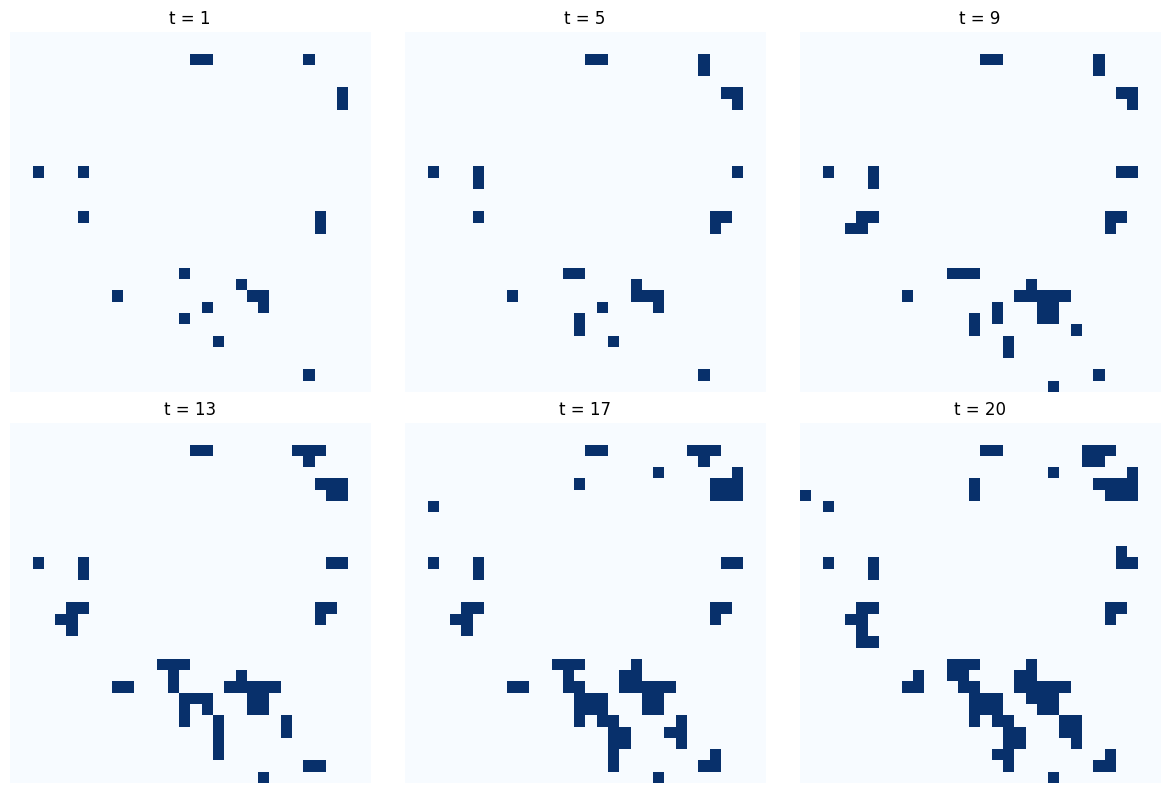

In [10]:
import matplotlib.pyplot as plt

history = run_flood(42)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

times = [0, 4, 8, 12, 16, 19]

for ax, t in zip(
    axes.flat,
    times,
):
    ax.imshow(
        history[t],
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    ax.set_title(
        f"t = {t + 1}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
flood = DynamicFloodModel(
    32,
    32,
    initial_flood_ratio=0.0,
    expansion_rate=0.15,
    rain_intensity=0.8,
    rain_variability=0.0,
    wind_influence=0.20,
    spontaneous_flood_probability=0.0,
    seed=1,
)

flood.reset(
    np.zeros((32, 32), dtype=np.int32),
    safe_coords=[],
    seed=1,
)

# Manually create one flood source
flood.flood_grid[:, :] = 0
flood.flood_grid[16, 16] = 1

print(
    "East candidate:",
    flood._expansion_probability(
        flooded_neighbors=1,
        wind_alignment=1.0,
        wind_strength=10.0 / 15.0,
    )
)

print(
    "West candidate:",
    flood._expansion_probability(
        flooded_neighbors=1,
        wind_alignment=-1.0,
        wind_strength=10.0 / 15.0,
    )
)

East candidate: 0.29833333333333334
West candidate: 0.165


stability test

In [13]:
from src.rescue_route.payload.stability import (
    PayloadStabilityModel,
)
from src.rescue_route.weather.wind import (
    WindModel,
)

wind = WindModel(
    base_speed=10.0,
    speed_std=0.0,
    gust_probability=0.0,
    seed=42,
)

wind.reset(seed=42)

# Force East wind.
wind.current_speed = 10.0
wind.current_direction = 90.0
wind.current_gust = 0.0

wind_state = wind.get_state()

In [14]:
standard = PayloadStabilityModel(
    payload_type="STANDARD",
    required_threshold=0.40,
)

fragile = PayloadStabilityModel(
    payload_type="FRAGILE",
    required_threshold=0.80,
)

standard.reset()
fragile.reset()

PayloadState(stability=1.0, payload_type='FRAGILE', required_threshold=0.8, is_damaged=False, catastrophic_damage=False, instability=0.0)

In [15]:
s = standard.step(
    action=0,
    move_vector=(0, -1),
    prev_move_vector=(0, 0),
    wind_state=wind_state,
)

f = fragile.step(
    action=0,
    move_vector=(0, -1),
    prev_move_vector=(0, 0),
    wind_state=wind_state,
)

print("Standard stability:", s.stability)
print("Fragile stability:", f.stability)

Standard stability: 0.99125
Fragile stability: 0.975


In [16]:
print(
    "Tailwind test:",
    fragile._calculate_crosswind(
        (1, 0),
        wind_state,
    )
)

Tailwind test: 6.123233995736766e-16


In [17]:
print(
    "Crosswind test:",
    fragile._calculate_crosswind(
        (0, -1),
        wind_state,
    )
)

Crosswind test: 10.0


In [18]:
fragile.reset()

straight = fragile._calculate_turn_severity(
    (1, 0),
    (1, 0),
)

ninety = fragile._calculate_turn_severity(
    (0, -1),
    (1, 0),
)

reverse = fragile._calculate_turn_severity(
    (-1, 0),
    (1, 0),
)

print("Straight:", straight)
print("90 degree:", ninety)
print("180 degree:", reverse)

Straight: 0.0
90 degree: 0.5
180 degree: 1.0


In [19]:
fragile.reset()

# Apply several strong disturbances.
for _ in range(5):
    state = fragile.step(
        action=0,
        move_vector=(0, -1),
        prev_move_vector=(0, -1),
        wind_state=wind_state,
    )

print(
    "Before hover:",
    state.stability
)

before_hover = state.stability

for _ in range(3):
    state = fragile.step(
        action=8,
        move_vector=(0, 0),
        prev_move_vector=(0, -1),
        wind_state=wind_state,
    )

print(
    "After hover:",
    state.stability
)

Before hover: 0.8749999999999999
After hover: 0.995


In [23]:
fragile = PayloadStabilityModel(
    payload_type="FRAGILE",
    required_threshold=0.80,
    alpha_wind=0.10,
    beta_gust=0.20,
    gamma_turn=0.10,
    catastrophic_threshold=0.15,
    
)
state = fragile.reset()

for _ in range(30):
    state = fragile.step(
        action=0,
        move_vector=(0, -1),
        prev_move_vector=(0, -1),
        wind_state=wind_state,
    )

    if state.catastrophic_damage:
        break

print("Stability:", state.stability)
print("Delivery-invalid:", state.is_damaged)
print("Catastrophic:", state.catastrophic_damage)

Stability: 0.10000000000000014
Delivery-invalid: True
Catastrophic: True


In [24]:
before = state.stability

for _ in range(5):
    state = fragile.step(
        action=8,
        move_vector=(0, 0),
        prev_move_vector=(0, -1),
        wind_state=wind_state,
    )

print("Before hover:", before)
print("After hover:", state.stability)

Before hover: 0.10000000000000014
After hover: 0.10000000000000014


In [25]:
from src.rescue_route.env.rescue_route_env import RescueRouteEnv

env = RescueRouteEnv(
    map_name="manhattan32",
    alpha_fc=0.80,
)

obs, info = env.reset(seed=42)

print(obs["spatial_tensor"].shape)
print(obs["vector_state"].shape)
print(info["payload_type"])

for _ in range(10):
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = (
        env.step(action)
    )

    print(
        "step:",
        info["step"],
        "stability:",
        round(
            info["payload_stability"],
            3,
        ),
        "damaged:",
        info["is_payload_damaged"],
    )

    if terminated or truncated:
        break

(7, 17, 17)
(15,)
STANDARD
step: 1 stability: 0.998 damaged: False
step: 2 stability: 0.965 damaged: False
step: 3 stability: 0.936 damaged: False
step: 4 stability: 0.915 damaged: False
step: 5 stability: 0.895 damaged: False
step: 6 stability: 0.886 damaged: False
step: 7 stability: 0.883 damaged: False


Forecast test

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))

from src.rescue_route.forecast.forecast_model import ForecastState
import inspect

print(inspect.signature(ForecastState))

(horizon_steps: 'int', flood_prob_map: 'np.ndarray', flood_prob_sequence: 'np.ndarray', forecast_wind_speed: 'float', forecast_wind_dir_deg: 'float', forecast_wind_speed_sequence: 'np.ndarray', forecast_wind_dir_sequence: 'np.ndarray', reliability_alpha: 'float') -> None


In [2]:
from src.rescue_route.env.rescue_route_env import RescueRouteEnv

env = RescueRouteEnv(
    map_name="manhattan32",
    alpha_fc=0.80,
)

obs, info = env.reset(seed=42)

print(
    "Forecast flood shape:",
    env.current_forecast.flood_prob_map.shape
)

print(
    "Forecast sequence shape:",
    env.current_forecast.flood_prob_sequence.shape
)

print(
    "Forecast wind:",
    env.current_forecast.forecast_wind_speed
)

print(
    "Forecast direction:",
    env.current_forecast.forecast_wind_dir_deg
)

Forecast flood shape: (32, 32)
Forecast sequence shape: (10, 32, 32)
Forecast wind: 5.2773566246032715
Forecast direction: 157.99623107910156


In [4]:
import numpy as np
forecast = env.current_forecast

print(
    "Minimum:",
    forecast.flood_prob_sequence.min()
)

print(
    "Maximum:",
    forecast.flood_prob_sequence.max()
)

print(
    "All valid:",
    np.all(
        (forecast.flood_prob_sequence >= 0.0)
        &
        (forecast.flood_prob_sequence <= 1.0)
    )
)

Minimum: 0.0
Maximum: 1.0
All valid: True


In [6]:
f1 = env.forecast_model.generate_forecast(
    env.flood_model.flood_grid,
    env.map_data.grid_map,
    env.wind_model.get_state(),
    current_rain_intensity=(
        env.flood_model.get_rain_intensity()
    ),
)

f2 = env.forecast_model.generate_forecast(
    env.flood_model.flood_grid,
    env.map_data.grid_map,
    env.wind_model.get_state(),
    current_rain_intensity=(
        env.flood_model.get_rain_intensity()
    ),
)
print(
    "Same probabilistic forecast:",
    np.allclose(
        f1.flood_prob_map,
        f2.flood_prob_map,
    )
)

Same probabilistic forecast: True


In [7]:
env1 = RescueRouteEnv(
    map_name="manhattan32",
    alpha_fc=0.80,
)

env2 = RescueRouteEnv(
    map_name="manhattan32",
    alpha_fc=0.80,
)

env1.reset(seed=123)
env2.reset(seed=124)

({'spatial_tensor': array([[[1.        , 1.        , 1.        , ..., 1.        ,
           1.        , 1.        ],
          [1.        , 1.        , 1.        , ..., 1.        ,
           1.        , 1.        ],
          [1.        , 1.        , 1.        , ..., 1.        ,
           1.        , 1.        ],
          ...,
          [1.        , 1.        , 1.        , ..., 0.        ,
           0.        , 0.        ],
          [1.        , 1.        , 1.        , ..., 0.        ,
           0.        , 0.        ],
          [1.        , 1.        , 1.        , ..., 0.        ,
           0.        , 0.        ]],
  
         [[0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          [0.        , 0.        , 0.        , ..., 0.        ,
           0.        , 0.        ],
          ...,
          [0.        , 0.        , 0.        , .

In [8]:
print(
    "Different forecast seeds:",
    not np.array_equal(
        env1.current_forecast.flood_prob_map,
        env2.current_forecast.flood_prob_map,
    )
)

Different forecast seeds: True


In [10]:
from src.rescue_route.forecast.forecast_model import ForecastModel
forecast_high = ForecastModel(
    horizon_steps=10,
    alpha_fc=0.90,
    seed=42,
)

forecast_medium = ForecastModel(
    horizon_steps=10,
    alpha_fc=0.50,
    seed=42,
)

forecast_low = ForecastModel(
    horizon_steps=10,
    alpha_fc=0.10,
    seed=42,
)

In [11]:
current_flood = env.flood_model.flood_grid
building_grid = env.map_data.grid_map
wind_state = env.wind_model.get_state()
rain = env.flood_model.get_rain_intensity()

In [12]:
fh = forecast_high.generate_forecast(
    current_flood,
    building_grid,
    wind_state,
    current_rain_intensity=rain,
)

fm = forecast_medium.generate_forecast(
    current_flood,
    building_grid,
    wind_state,
    current_rain_intensity=rain,
)

fl = forecast_low.generate_forecast(
    current_flood,
    building_grid,
    wind_state,
    current_rain_intensity=rain,
)

In [13]:
print(
    "High mean:",
    fh.flood_prob_map.mean()
)

print(
    "Medium mean:",
    fm.flood_prob_map.mean()
)

print(
    "Low mean:",
    fl.flood_prob_map.mean()
)

High mean: 0.05426811
Medium mean: 0.053803466
Low mean: 0.05333882


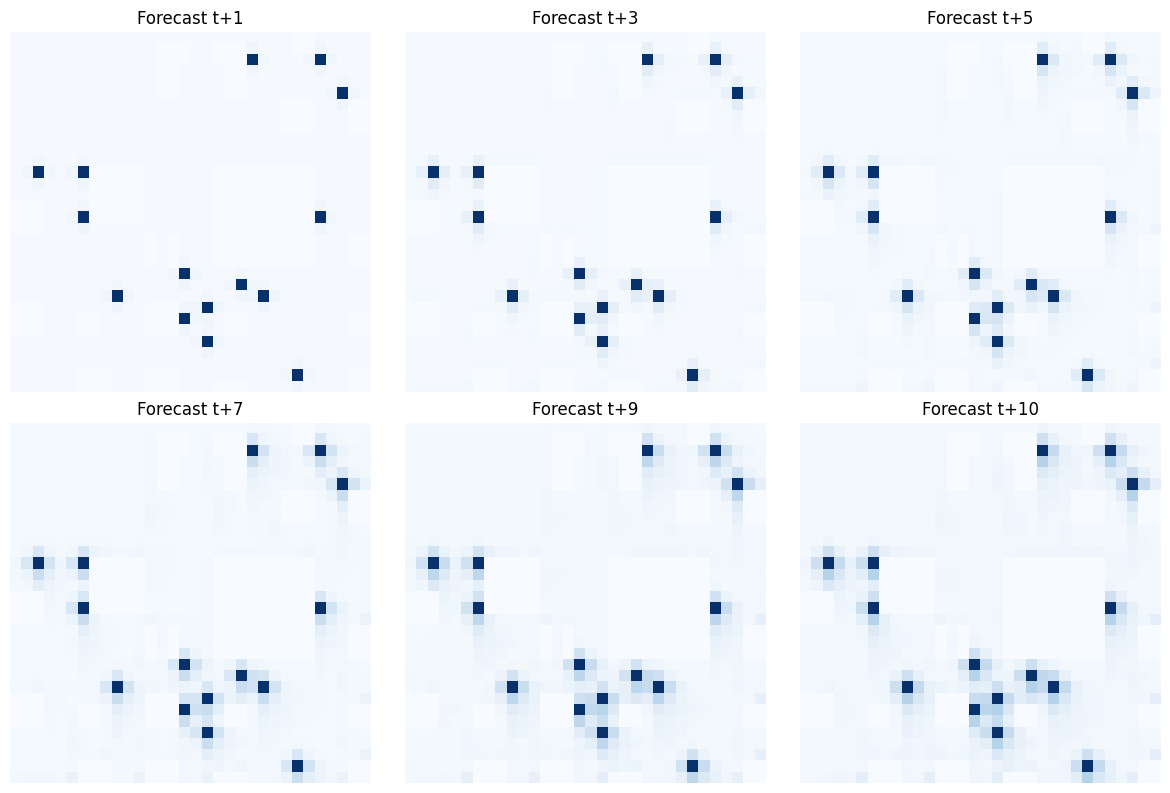

In [14]:
import matplotlib.pyplot as plt

forecast_seq = (
    env.current_forecast
    .flood_prob_sequence
)

times = [0, 2, 4, 6, 8, 9]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

for ax, t in zip(
    axes.flat,
    times,
):
    ax.imshow(
        forecast_seq[t],
        cmap="Blues",
        vmin=0,
        vmax=1,
    )

    ax.set_title(
        f"Forecast t+{t+1}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

test new fix in mission

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))

In [2]:
from src.rescue_route.map.map_loader import load_map
from src.rescue_route.env.mission import generate_mission

map_data = load_map("manhattan32")

m = generate_mission(
    map_data,
    seed=42,
)

print(m)

MissionConfig(mission_id=42, seed=42, map_name='manhattan32', start_pos=(2, 2), target_pos=(29, 30), initial_battery=629.4049621228859, deadline_steps=66, payload_type='STANDARD', required_stability=0.4, wind_base_speed=10.981905023361954, wind_speed_std=3.017195839822765, wind_correlation=0.85, wind_gust_probability=0.27171958398227647, wind_max_gust=10.095026687432847, wind_min_gust=2.0, wind_direction_drift_deg=15.0, flood_initial_ratio=0.021825650544863077, flood_expansion_rate=0.045286170980753535, rain_intensity=0.673026021794523, rain_variability=0.1846052043589046, rain_correlation=0.85, flood_wind_influence=0.05, flood_spontaneous_probability=0.001, forecast_horizon=10, forecast_reliability=0.5423798065494423)


In [3]:
print("Mission:", m.mission_id)

print("\n--- Mission ---")
print("Start:", m.start_pos)
print("Target:", m.target_pos)
print("Battery:", round(m.initial_battery, 2))
print("Deadline:", m.deadline_steps)

print("\n--- Payload ---")
print("Type:", m.payload_type)
print("Required stability:", m.required_stability)

print("\n--- Wind ---")
print("Base speed:", round(m.wind_base_speed, 2))
print("Speed std:", round(m.wind_speed_std, 2))
print("Gust probability:", round(m.wind_gust_probability, 2))
print("Max gust:", round(m.wind_max_gust, 2))

print("\n--- Flood ---")
print("Initial ratio:", round(m.flood_initial_ratio, 3))
print("Expansion rate:", round(m.flood_expansion_rate, 3))
print("Rain intensity:", round(m.rain_intensity, 3))
print("Rain variability:", round(m.rain_variability, 3))

print("\n--- Forecast ---")
print("Reliability:", round(m.forecast_reliability, 3))
print("Horizon:", m.forecast_horizon)

Mission: 42

--- Mission ---
Start: (2, 2)
Target: (29, 30)
Battery: 629.4
Deadline: 66

--- Payload ---
Type: STANDARD
Required stability: 0.4

--- Wind ---
Base speed: 10.98
Speed std: 3.02
Gust probability: 0.27
Max gust: 10.1

--- Flood ---
Initial ratio: 0.022
Expansion rate: 0.045
Rain intensity: 0.673
Rain variability: 0.185

--- Forecast ---
Reliability: 0.542
Horizon: 10


In [4]:
m1 = generate_mission(
    map_data,
    seed=123,
)

m2 = generate_mission(
    map_data,
    seed=123,
)

print("Same mission:", m1 == m2)

Same mission: True


In [5]:
m3 = generate_mission(
    map_data,
    seed=124,
)

print(
    "Different environment:",
    m1.wind_base_speed != m3.wind_base_speed
    or m1.rain_intensity != m3.rain_intensity
    or m1.forecast_reliability != m3.forecast_reliability
)

Different environment: True


In [6]:
for seed in range(20):

    m = generate_mission(
        map_data,
        seed=seed,
    )

    print(
        f"{seed:02d} | "
        f"wind={m.wind_base_speed:.2f} | "
        f"rain={m.rain_intensity:.2f} | "
        f"flood_rate={m.flood_expansion_rate:.3f} | "
        f"forecast={m.forecast_reliability:.2f} | "
        f"payload={m.payload_type}"
    )

00 | wind=5.10 | rain=0.16 | flood_rate=0.022 | forecast=0.87 | payload=FRAGILE
01 | wind=5.84 | rain=0.86 | flood_rate=0.054 | forecast=0.64 | payload=STANDARD
02 | wind=10.66 | rain=0.22 | flood_rate=0.025 | forecast=0.77 | payload=FRAGILE
03 | wind=10.57 | rain=0.59 | flood_rate=0.041 | forecast=0.54 | payload=STANDARD
04 | wind=11.83 | rain=0.21 | flood_rate=0.024 | forecast=0.77 | payload=FRAGILE
05 | wind=8.51 | rain=0.36 | flood_rate=0.031 | forecast=0.52 | payload=STANDARD
06 | wind=7.46 | rain=0.43 | flood_rate=0.034 | forecast=0.94 | payload=STANDARD
07 | wind=10.38 | rain=0.32 | flood_rate=0.029 | forecast=0.64 | payload=FRAGILE
08 | wind=7.09 | rain=0.74 | flood_rate=0.048 | forecast=0.89 | payload=STANDARD
09 | wind=9.14 | rain=0.73 | flood_rate=0.048 | forecast=0.82 | payload=FRAGILE
10 | wind=10.76 | rain=0.26 | flood_rate=0.027 | forecast=0.73 | payload=FRAGILE
11 | wind=9.13 | rain=0.17 | flood_rate=0.023 | forecast=0.57 | payload=STANDARD
12 | wind=6.16 | rain=0.28 | 

test the changes in rescue route env py

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT))

In [2]:
from src.rescue_route.env.rescue_route_env import RescueRouteEnv

env = RescueRouteEnv(
    map_name="manhattan32"
)

obs, info = env.reset(seed=42)

print("Mission:", info["mission_id"])
print("Seed:", info["scenario_seed"])

print("\n--- WIND ---")
print(
    "Configured:",
    info["wind_base_speed"]
)
print(
    "Actual:",
    info["wind_speed"]
)
print(
    "STD:",
    info["wind_speed_std"]
)
print(
    "Gust prob:",
    info["wind_gust_probability"]
)

print("\n--- FLOOD ---")
print(
    "Rain:",
    info["rain_intensity"]
)
print(
    "Expansion:",
    info["flood_expansion_rate"]
)

print("\n--- FORECAST ---")
print(
    "Reliability:",
    info["forecast_reliability"]
)
print(
    "Horizon:",
    env.mission.forecast_horizon
)

Mission: 42
Seed: 42

--- WIND ---
Configured: 10.981905023361954
Actual: 11.901296128719965
STD: 3.017195839822765
Gust prob: 0.27171958398227647

--- FLOOD ---
Rain: 0.7292783805742384
Expansion: 0.045286170980753535

--- FORECAST ---
Reliability: 0.5423798065494423
Horizon: 10


In [3]:
print(
    "Wind base matches mission:",
    env.wind_model.base_speed
    == env.mission.wind_base_speed
)

print(
    "Wind std matches mission:",
    env.wind_model.speed_std
    == env.mission.wind_speed_std
)

print(
    "Gust probability matches mission:",
    env.wind_model.gust_prob
    == env.mission.wind_gust_probability
)

print(
    "Flood expansion matches mission:",
    env.flood_model.expansion_rate
    == env.mission.flood_expansion_rate
)

print(
    "Forecast reliability matches mission:",
    env.alpha_fc
    == env.mission.forecast_reliability
)

Wind base matches mission: True
Wind std matches mission: True
Gust probability matches mission: True
Flood expansion matches mission: True
Forecast reliability matches mission: True


In [4]:
env_a = RescueRouteEnv("manhattan32")
obs_a, info_a = env_a.reset(seed=100)

env_b = RescueRouteEnv("manhattan32")
obs_b, info_b = env_b.reset(seed=101)

print(
    "Different wind scenarios:",
    info_a["wind_base_speed"]
    != info_b["wind_base_speed"]
)

print(
    "Different rain scenarios:",
    info_a["rain_intensity"]
    != info_b["rain_intensity"]
)

print(
    "Different forecast reliability:",
    info_a["forecast_reliability"]
    != info_b["forecast_reliability"]
)

Different wind scenarios: True
Different rain scenarios: True
Different forecast reliability: True


In [5]:
env1 = RescueRouteEnv("manhattan32")
env2 = RescueRouteEnv("manhattan32")

obs1, info1 = env1.reset(seed=555)
obs2, info2 = env2.reset(seed=555)

print(
    "Same wind config:",
    info1["wind_base_speed"]
    == info2["wind_base_speed"]
)

print(
    "Same wind std:",
    info1["wind_speed_std"]
    == info2["wind_speed_std"]
)

print(
    "Same rain:",
    info1["rain_intensity"]
    == info2["rain_intensity"]
)

print(
    "Same forecast reliability:",
    info1["forecast_reliability"]
    == info2["forecast_reliability"]
)

Same wind config: True
Same wind std: True
Same rain: True
Same forecast reliability: True


In [6]:
obs, info = env.reset(seed=42)

for i in range(20):

    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = (
        env.step(action)
    )

    print(
        f"step={info['step']:02d} | "
        f"pos={info['drone_pos']} | "
        f"battery={info['battery_remaining']:.2f} | "
        f"wind={info['wind_speed']:.2f} | "
        f"rain={info['rain_intensity']:.2f} | "
        f"stability={info['payload_stability']:.3f}"
    )

    if terminated or truncated:
        print(
            "Episode ended:",
            info["terminated_reason"]
        )
        break

step=01 | pos=(3, 1) | battery=627.90 | wind=12.96 | rain=0.71 | stability=0.990
step=02 | pos=(2, 0) | battery=626.24 | wind=12.86 | rain=0.74 | stability=0.956
step=03 | pos=(3, 1) | battery=625.05 | wind=13.98 | rain=0.86 | stability=0.923
step=04 | pos=(2, 1) | battery=624.07 | wind=15.32 | rain=0.79 | stability=0.893
step=05 | pos=(3, 0) | battery=622.44 | wind=13.15 | rain=0.76 | stability=0.858
step=06 | pos=(2, 1) | battery=621.27 | wind=12.53 | rain=0.65 | stability=0.832
step=07 | pos=(2, 2) | battery=620.46 | wind=12.05 | rain=0.58 | stability=0.825
step=08 | pos=(1, 1) | battery=618.91 | wind=12.47 | rain=0.54 | stability=0.790
step=09 | pos=(0, 0) | battery=617.32 | wind=15.65 | rain=0.66 | stability=0.774
step=10 | pos=(0, 0) | battery=616.40 | wind=15.65 | rain=0.66 | stability=0.756
Episode ended: BOUNDARY_CRASH


In [7]:
print("Mission wind:")
print(env.mission.wind_base_speed)

print("\nModel wind:")
print(env.wind_model.base_speed)

print("\nMission rain:")
print(env.mission.rain_intensity)

print("\nModel rain:")
print(env.flood_model.rain_intensity)

print("\nMission forecast reliability:")
print(env.mission.forecast_reliability)

print("\nEnvironment forecast reliability:")
print(env.alpha_fc)

Mission wind:
10.981905023361954

Model wind:
10.981905023361954

Mission rain:
0.673026021794523

Model rain:
0.6582285364200942

Mission forecast reliability:
0.5423798065494423

Environment forecast reliability:
0.5423798065494423
